This file is for trying various kind of models to test their performance

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV

import optuna

In [17]:
def score_to_class(score):
    if score < 50: return "Fail"
    elif score < 75: return "Pass"
    else: return "Success"

v_score_to_class = np.vectorize(score_to_class)

In [18]:
df = pd.read_csv('filtered_data.csv')
df.dropna(inplace=True)
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [19]:
print(df.columns.tolist())

['Attendance', 'Hours_Studied', 'Support_Multiplier', 'Overcoming_Odds', 'Disadvantage_Score', 'Tutoring_Sessions', 'Motivation_Sustainability', 'Access_to_Resources', 'Parental_Education_Level', 'Previous_Scores', 'Inefficiency_Flag', 'Teacher_Quality', 'Motivation_Level', 'Effort_Payoff', 'Family_Income', 'Sleep_Hours', 'Physical_Activity', 'Peer_Influence', 'Support_Index', 'Resilience_Score', 'Exam_Score']


In [20]:
numerical_cols = [
    'Attendance', 'Hours_Studied', 'Support_Multiplier', 'Overcoming_Odds',
    'Disadvantage_Score', 'Tutoring_Sessions', 'Motivation_Sustainability',
    'Previous_Scores', 'Effort_Payoff', 'Sleep_Hours', 'Physical_Activity',
    'Support_Index', 'Resilience_Score'
]

ordinal_cols = [
    'Access_to_Resources', 'Teacher_Quality', 'Motivation_Level',
    'Family_Income', 'Peer_Influence', 'Parental_Education_Level'
]

ordinal_categories = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Negative', 'Neutral', 'Positive'],
    ['High School', 'College', 'Postgraduate']
]

nominal_cols = ['Inefficiency_Flag']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ]
)

# Process all data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


In [21]:
def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['XGBoost', 'SVR', 'Random Forest', 'Lasso', 'LightGBM', 'KNeighborsRegressor'])

    if classifier_name == 'XGBoost':
        params = {
            "n_estimators": trial.suggest_int("xgb_n_estimators", 100, 300),
            "learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.1),
            "max_depth": trial.suggest_int("xgb_max_depth", 3, 7),
            "subsample": trial.suggest_float("xgb_subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.7, 1.0),
            "device": "cuda"
        }
        model = XGBRegressor(**params)
        model.fit(X_train_processed, y_train, eval_set=[(X_val_processed, y_val)], verbose=False)
    elif classifier_name == 'SVR':
        params = {
            'C': trial.suggest_float('svr_C', 0.1, 100),
            'kernel': trial.suggest_categorical("svr_kernel", ["rbf", "poly", "linear"]),
            'epsilon': trial.suggest_float('svr_epsilon', 0.01, 0.5)
        }
        model = SVR(**params)
        model.fit(X_train_processed, y_train)
    elif classifier_name == "Random Forest":
        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators", 100, 300),
            "max_depth": trial.suggest_int("rf_max_depth", 10, 30),
            "min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 10),
            "max_features": trial.suggest_categorical("rf_max_features", ["sqrt", "log2"])
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train_processed, y_train)
    elif classifier_name == "Lasso":
        params = {
            "alpha": trial.suggest_float("lasso_alpha", 0.001, 10),
            "max_iter": trial.suggest_int("lasso_max_iter", 1000, 10000)
        }
        model = Lasso(**params)
        model.fit(X_train_processed, y_train)
    elif classifier_name == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int("lgbm_n_estimators", 100, 300),
            "learning_rate": trial.suggest_float("lgbm_learning_rate", 0.01, 0.1),
            "num_leaves": trial.suggest_int("lgmb_num_leaves", 31, 100),
            "max_depth": trial.suggest_int("lgbm_max_depth", 3, 20),
            "subsample": trial.suggest_float("lgbm_subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("lgbm_colsample_bytree", 0.7, 1.0)
        }
        model = LGBMRegressor(**params)
        model.fit(
            X_train_processed, y_train,
            eval_set=[(X_val_processed, y_val)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
        )
    elif classifier_name == "KNeighborsRegressor":
        params = {
            "n_neighbors": trial.suggest_int("knn_n_neighbors", 3, 9),
            "weights": trial.suggest_categorical("knn_weights", ["uniform", "distance"]),
            "metric": trial.suggest_categorical("knn_metric", ["euclidean", "manhattan", "minkowski"]), 
            "p": trial.suggest_int("knn_p", 1, 2)
        }
        model = KNeighborsRegressor(**params)
        model.fit(X_train_processed, y_train)

    preds = model.predict(X_val_processed)
    rmse = root_mean_squared_error(y_val, preds)
    
    return rmse


In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:")
print(f"  RMSE: {study.best_value:.4f}")
print(f"  Params: {study.best_params}")


[I 2026-04-03 22:48:53,343] A new study created in memory with name: no-name-044e0268-ae56-4b6c-b9c1-9e5caf38fa1c
Best trial: 0. Best value: 2.59634:   2%|▏         | 1/50 [00:00<00:06,  8.10it/s]

[I 2026-04-03 22:48:53,466] Trial 0 finished with value: 2.5963373254017843 and parameters: {'classifier': 'KNeighborsRegressor', 'knn_n_neighbors': 8, 'knn_weights': 'uniform', 'knn_metric': 'minkowski', 'knn_p': 2}. Best is trial 0 with value: 2.5963373254017843.


Best trial: 1. Best value: 2.35966:   4%|▍         | 2/50 [00:00<00:11,  4.29it/s]

[I 2026-04-03 22:48:53,776] Trial 1 finished with value: 2.3596625328063965 and parameters: {'classifier': 'XGBoost', 'xgb_n_estimators': 195, 'xgb_learning_rate': 0.06374734597547313, 'xgb_max_depth': 3, 'xgb_subsample': 0.8063387818248444, 'xgb_colsample_bytree': 0.9885889512374415}. Best is trial 1 with value: 2.3596625328063965.
[I 2026-04-03 22:48:53,783] Trial 2 finished with value: 2.8419572531254245 and parameters: {'classifier': 'Lasso', 'lasso_alpha': 0.8085411218592421, 'lasso_max_iter': 2994}. Best is trial 1 with value: 2.3596625328063965.


Best trial: 1. Best value: 2.35966:   8%|▊         | 4/50 [00:00<00:10,  4.56it/s]

...

[I 2026-04-03 22:54:44,731] Trial 45 finished with value: 2.2730512304229262 and parameters: {'classifier': 'SVR', 'svr_C': 71.25307760952936, 'svr_kernel': 'linear', 'svr_epsilon': 0.15048602742287348}. Best is trial 24 with value: 2.272914417058573.


Best trial: 24. Best value: 2.27291:  94%|█████████▍| 47/50 [06:11<00:57, 19.19s/it]

[I 2026-04-03 22:55:04,565] Trial 46 finished with value: 2.273176295842948 and parameters: {'classifier': 'SVR', 'svr_C': 71.89471144674879, 'svr_kernel': 'linear', 'svr_epsilon': 0.15748663928273515}. Best is trial 24 with value: 2.272914417058573.


Best trial: 24. Best value: 2.27291:  96%|█████████▌| 48/50 [06:11<00:27, 13.84s/it]c:\Users\Aybars\miniconda3\envs\student_analysis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 24. Best value: 2.27291: 100%|██████████| 50/50 [06:11<00:00,  7.44s/it]

[I 2026-04-03 22:55:05,207] Trial 47 finished with value: 2.44563184576924 and parameters: {'classifier': 'Random Forest', 'rf_n_estimators': 211, 'rf_max_depth': 18, 'rf_min_samples_split': 10, 'rf_max_features': 'log2'}. Best is trial 24 with value: 2.272914417058573.
[I 2026-04-03 22:55:05,225] Trial 48 finished with value: 2.717721080838614 and parameters: {'classifier': 'KNeighborsRegressor', 'knn_n_neighbors': 5, 'knn_weights': 'distance', 'knn_metric': 'manhattan', 'knn_p': 2}. Best is trial 24 with value: 2.272914417058573.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 910
[LightGBM] [Info] Number of data points in the train set: 4123, number of used features: 20
[LightGBM] [Info] Start training from score 67.278681
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, b

In [ ]:
X_train_combined = np.vstack([X_train_processed, X_val_processed])
y_train_combined = np.concatenate([y_train, y_val])

best_params = study.best_params.copy()
classifier_name = best_params.pop('classifier')

if classifier_name == 'XGBoost':
    model_params = {k.replace('xgb_', ''): v for k, v in best_params.items() if k.startswith('xgb_')}
    best_model = XGBRegressor(**model_params, device='cuda')
    best_model.fit(X_train_combined, y_train_combined, verbose=False)
elif classifier_name == 'SVR':
    model_params = {k.replace('svr_', ''): v for k, v in best_params.items() if k.startswith('svr_')}
    best_model = SVR(**model_params)
    best_model.fit(X_train_combined, y_train_combined)
elif classifier_name == 'Random Forest':
    model_params = {k.replace('rf_', ''): v for k, v in best_params.items() if k.startswith('rf_')}
    best_model = RandomForestRegressor(**model_params)
    best_model.fit(X_train_combined, y_train_combined)
elif classifier_name == 'Lasso':
    model_params = {k.replace('lasso_', ''): v for k, v in best_params.items() if k.startswith('lasso_')}
    best_model = Lasso(**model_params)
    best_model.fit(X_train_combined, y_train_combined)
elif classifier_name == 'LightGBM':
    model_params = {k.replace('lgbm_', '').replace('lgmb_', ''): v for k, v in best_params.items() if k.startswith('lgbm_') or k.startswith('lgmb_')}
    best_model = LGBMRegressor(**model_params)
    best_model.fit(X_train_combined, y_train_combined, callbacks=[lgb.log_evaluation(0)])
elif classifier_name == 'KNeighborsRegressor':
    model_params = {k.replace('knn_', ''): v for k, v in best_params.items() if k.startswith('knn_')}
    best_model = KNeighborsRegressor(**model_params)
    best_model.fit(X_train_combined, y_train_combined)

# Evaluate on test set
y_pred = best_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

y_test_class = v_score_to_class(y_test.values)
y_pred_class = v_score_to_class(y_pred)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class, average='weighted', zero_division=0)
recall = recall_score(y_test_class, y_pred_class, average='weighted', zero_division=0)
f1 = f1_score(y_test_class, y_pred_class, average='weighted', zero_division=0)

print("\n" + "="*60)
print("BEST MODEL RESULTS (TEST SET)")
print("="*60)
print(f"Model: {classifier_name}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print("="*60)



BEST MODEL RESULTS (TEST SET)
Model: SVR
MAE: 0.6495
RMSE: 1.7862
R²: 0.7821
Accuracy: 0.9868
Precision: 0.9852
Recall: 0.9868
F1: 0.9845



TOP 10 TRIALS BY RMSE
 number    value    state
     24 2.272914 COMPLETE
     44 2.272939 COMPLETE
     31 2.272950 COMPLETE
     43 2.273025 COMPLETE
     45 2.273051 COMPLETE
     25 2.273054 COMPLETE
     23 2.273055 COMPLETE
     30 2.273060 COMPLETE
     33 2.273103 COMPLETE
     41 2.273129 COMPLETE


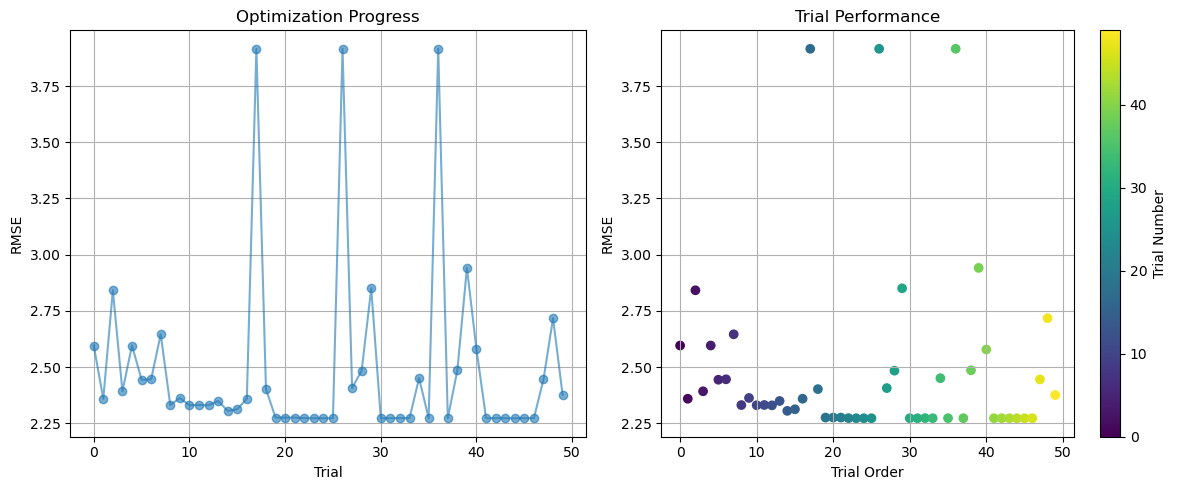

In [ ]:
trials_df = study.trials_dataframe()
trials_df_sorted = trials_df.sort_values('value').head(10)

print("\n" + "="*100)
print("TOP 10 TRIALS BY RMSE")
print("="*100)
print(trials_df_sorted[['number', 'value', 'state']].to_string(index=False))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.6)
plt.xlabel('Trial')
plt.ylabel('RMSE')
plt.title('Optimization Progress')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(range(len(trials_df)), trials_df['value'].values, c=trials_df['number'], cmap='viridis')
plt.xlabel('Trial Order')
plt.ylabel('RMSE')
plt.title('Trial Performance')
plt.colorbar(label='Trial Number')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "="*100)
print("BEST PERFORMANCE FOR EACH MODEL (TEST SET)")
print("="*100)

all_trials = study.trials_dataframe()
models_to_test = ['XGBoost', 'SVR', 'Random Forest', 'Lasso', 'LightGBM', 'KNeighborsRegressor']
comparison_results = []

for model_name in models_to_test:
    model_trials = all_trials[all_trials['params_classifier'] == model_name]
    if len(model_trials) == 0:
        continue
    
    best_trial_idx = model_trials['value'].idxmin()
    best_trial = study.trials[best_trial_idx]
    
    best_params = best_trial.params.copy()
    best_params.pop('classifier')
    
    # Rename parameters
    if model_name == 'XGBoost':
        model_params = {k.replace('xgb_', ''): v for k, v in best_params.items() if k.startswith('xgb_')}
        test_model = XGBRegressor(**model_params, device='cuda')
    elif model_name == 'SVR':
        model_params = {k.replace('svr_', ''): v for k, v in best_params.items() if k.startswith('svr_')}
        test_model = SVR(**model_params)
    elif model_name == 'Random Forest':
        model_params = {k.replace('rf_', ''): v for k, v in best_params.items() if k.startswith('rf_')}
        test_model = RandomForestRegressor(**model_params)
    elif model_name == 'Lasso':
        model_params = {k.replace('lasso_', ''): v for k, v in best_params.items() if k.startswith('lasso_')}
        test_model = Lasso(**model_params)
    elif model_name == 'LightGBM':
        model_params = {k.replace('lgbm_', '').replace('lgmb_', ''): v for k, v in best_params.items() if k.startswith('lgbm_') or k.startswith('lgmb_')}
        test_model = LGBMRegressor(**model_params)
    elif model_name == 'KNeighborsRegressor':
        model_params = {k.replace('knn_', ''): v for k, v in best_params.items() if k.startswith('knn_')}
        test_model = KNeighborsRegressor(**model_params)
    
    # Train on combined data
    if model_name in ['XGBoost', 'LightGBM']:
        if model_name == 'XGBoost':
            test_model.fit(X_train_combined, y_train_combined, verbose=False)
        else:
            test_model.fit(X_train_combined, y_train_combined, callbacks=[lgb.log_evaluation(0)])
    else:
        test_model.fit(X_train_combined, y_train_combined)
    
    # Evaluate
    y_pred = test_model.predict(X_test_processed)
    
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    
    y_pred_class = v_score_to_class(y_pred)
    test_accuracy = accuracy_score(y_test_class, y_pred_class)
    test_precision = precision_score(y_test_class, y_pred_class, average='weighted', zero_division=0)
    test_recall = recall_score(y_test_class, y_pred_class, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test_class, y_pred_class, average='weighted', zero_division=0)
    
    comparison_results.append({
        'Model': model_name,
        'Val_RMSE': best_trial.value,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Test_R²': test_r2,
        'Test_Accuracy': test_accuracy,
        'Test_F1': test_f1
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df_sorted = comparison_df.sort_values('Test_R²', ascending=False)

print(comparison_df_sorted.to_string(index=False))
print("="*100)



BEST PERFORMANCE FOR EACH MODEL (TEST SET)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 5154, number of used features: 20
[LightGBM] [Info] Start training from score 67.262515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

c:\Users\Aybars\miniconda3\envs\student_analysis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


====================================================================================================
BEST PERFORMANCE FOR EACH MODEL (TEST SET)
====================================================================================================
              Model  Val_RMSE  Test_MAE  Test_RMSE  Test_R²  Test_Accuracy  Test_F1
                SVR  2.272914  0.649515   1.786168 0.782101       0.986811 0.984528
           LightGBM  2.349689  0.811957   1.866089 0.762165       0.982157 0.979068
            XGBoost  2.359663  0.800956   1.921160 0.747921       0.982933 0.979661
      Random Forest  2.444104  1.002966   1.975430 0.733478       0.980605 0.971003
KNeighborsRegressor  2.596337  1.238751   2.192199 0.671776       0.980605 0.971003
              Lasso  2.841957  1.659159   2.526949 0.563883       0.980605 0.971003
====================================================================================================

In [29]:
pd.set_option("display.max_columns", 200)
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_classifier,params_knn_metric,params_knn_n_neighbors,params_knn_p,params_knn_weights,params_lasso_alpha,params_lasso_max_iter,params_lgbm_colsample_bytree,params_lgbm_learning_rate,params_lgbm_max_depth,params_lgbm_n_estimators,params_lgbm_subsample,params_lgmb_num_leaves,params_rf_max_depth,params_rf_max_features,params_rf_min_samples_split,params_rf_n_estimators,params_svr_C,params_svr_epsilon,params_svr_kernel,params_xgb_colsample_bytree,params_xgb_learning_rate,params_xgb_max_depth,params_xgb_n_estimators,params_xgb_subsample,state
0,0,2.596337,2026-04-03 22:48:53.345784,2026-04-03 22:48:53.466236,0 days 00:00:00.120452,KNeighborsRegressor,minkowski,8.0,2.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,2.359663,2026-04-03 22:48:53.469235,2026-04-03 22:48:53.776794,0 days 00:00:00.307559,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988589,0.063747,3.0,195.0,0.806339,COMPLETE
2,2,2.841957,2026-04-03 22:48:53.778793,2026-04-03 22:48:53.783301,0 days 00:00:00.004508,Lasso,NaN,NaN,NaN,NaN,0.808541,2994.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
3,3,2.392862,2026-04-03 22:48:53.784302,2026-04-03 22:48:54.198925,0 days 00:00:00.414623,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.779985,0.098864,6.0,153.0,0.724962,COMPLETE
4,4,2.596337,2026-04-03 22:48:54.200457,2026-04-03 22:48:54.206790,0 days 00:00:00.006333,KNeighborsRegressor,minkowski,8.0,2.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
5,5,2.444104,2026-04-03 22:48:54.208860,2026-04-03 22:48:54.950890,0 days 00:00:00.742030,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,log2,8.0,252.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
6,6,2.446065,2026-04-03 22:48:54.952890,2026-04-03 22:48:55.786206,0 days 00:00:00.833316,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,log2,7.0,280.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
7,7,2.646184,2026-04-03 22:48:55.788206,2026-04-03 22:48:55.799206,0 days 00:00:00.011000,KNeighborsRegressor,minkowski,8.0,1.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
8,8,2.331565,2026-04-03 22:48:55.801206,2026-04-03 22:48:57.966479,0 days 00:00:02.165273,SVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.897155,0.298873,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
9,9,2.363086,2026-04-03 22:48:57.968484,2026-04-03 22:48:58.230756,0 days 00:00:00.262272,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.810515,0.072124,3.0,188.0,0.704311,COMPLETE
